In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

yield_df = pd.read_csv('yield.csv.csv')
yield_df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1991,1991,kg/ha,1139.6,E,Estimated value,NaN
1,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1992,1992,kg/ha,1125.0,E,Estimated value,NaN
2,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1993,1993,kg/ha,1154.3,E,Estimated value,NaN
3,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1994,1994,kg/ha,1139.7,E,Estimated value,NaN
4,QCL,Crops and livestock products,404,Kenya,5412,Yield,1929.07,"Abaca, manila hemp, raw",1995,1995,kg/ha,1126.1,E,Estimated value,NaN


In [28]:
print(yield_df.shape)
print("\nColumns:")
print(yield_df.columns.tolist())

(4396, 15)

Columns:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


# Renaming columns to lowercase

In [29]:
yield_df = yield_df.rename(columns={
    "Area": "area",
    "Item": "item",
    "Year" : "year",
    "Unit" :"unit",
    "Value": "yield_kg_per_ha"
    
})

## Fixing the year datatype

In [30]:
yield_df['year'] = yield_df['year'].astype(int)

## Checking for duplicates

In [31]:
print( "Total number of duplicate rows:", yield_df.duplicated().sum())

Total number of duplicate rows: 0


In [32]:
# Final clean dataset
yield_clean = yield_df[['item','year','unit','yield_kg_per_ha']].copy()

In [33]:
print(yield_clean.shape)
print(yield_clean.head())

(4396, 4)
                      item  year   unit  yield_kg_per_ha
0  Abaca, manila hemp, raw  1991  kg/ha           1139.6
1  Abaca, manila hemp, raw  1992  kg/ha           1125.0
2  Abaca, manila hemp, raw  1993  kg/ha           1154.3
3  Abaca, manila hemp, raw  1994  kg/ha           1139.7
4  Abaca, manila hemp, raw  1995  kg/ha           1126.1


## Exploratory Data Analysis

In [34]:
print(yield_clean.info())
print("\nSummary Statistics:")
print(yield_clean.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4396 entries, 0 to 4395
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item             4396 non-null   object 
 1   year             4396 non-null   int64  
 2   unit             4396 non-null   object 
 3   yield_kg_per_ha  4396 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 137.5+ KB
None

Summary Statistics:
              year  yield_kg_per_ha
count  4396.000000      4396.000000
mean   1996.414468      7076.352116
std      17.810920     11569.827178
min    1961.000000        33.300000
25%    1982.000000       833.300000
50%    1998.000000      4000.000000
75%    2011.000000      9760.350000
max    2024.000000    121184.500000


## Top Crops by average yield

In [35]:
top_crops = (yield_clean.groupby('item')['yield_kg_per_ha']
             .mean()
             .sort_values(ascending=False)
             .head(15))

print("\nTop 15 Crops by Average Yield (kg/ha):")
print(top_crops)


Top 15 Crops by Average Yield (kg/ha):
item
Sugar cane                       76965.676562
Pineapples                       39807.071875
Cabbages                         24246.673529
Carrots and turnips              19456.739394
Watermelons                      17306.766667
Tomatoes                         16656.681250
Bananas                          14548.820312
Avocados                         14324.610937
Spinach                          14237.400000
Cauliflowers and broccoli        14188.621212
Plantains and cooking bananas    13356.946875
Green garlic                     13250.003125
Lettuce and chicory              12049.385294
Papayas                          11373.837500
Cucumbers and gherkins           10137.300000
Name: yield_kg_per_ha, dtype: float64


## VISUALIZATION

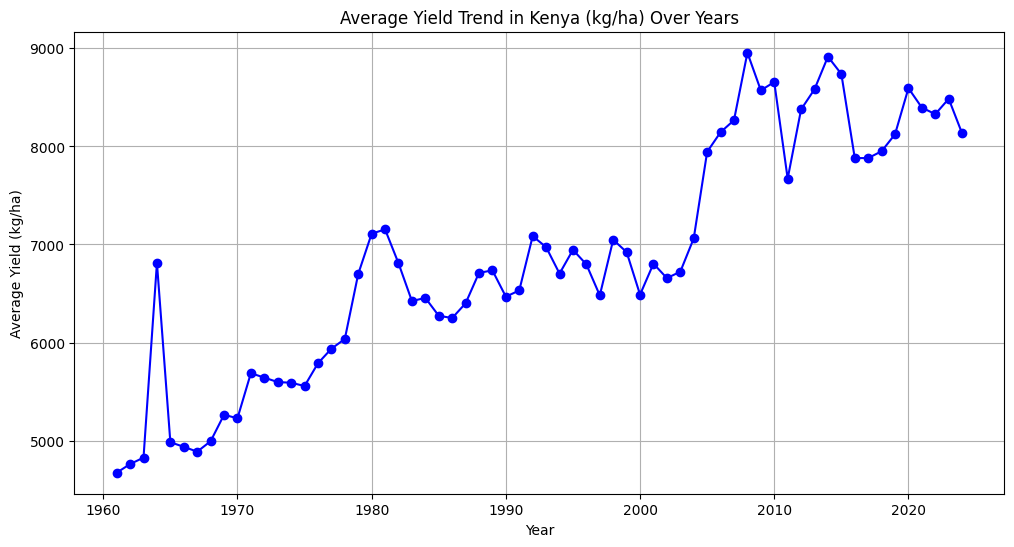

In [36]:
plt.figure(figsize=(12,6))
yield_clean.groupby('year')['yield_kg_per_ha'].mean().plot(kind='line',marker='o',color='blue')
plt.title('Average Yield Trend in Kenya (kg/ha) Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.grid(True)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_20208\2285299805.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(


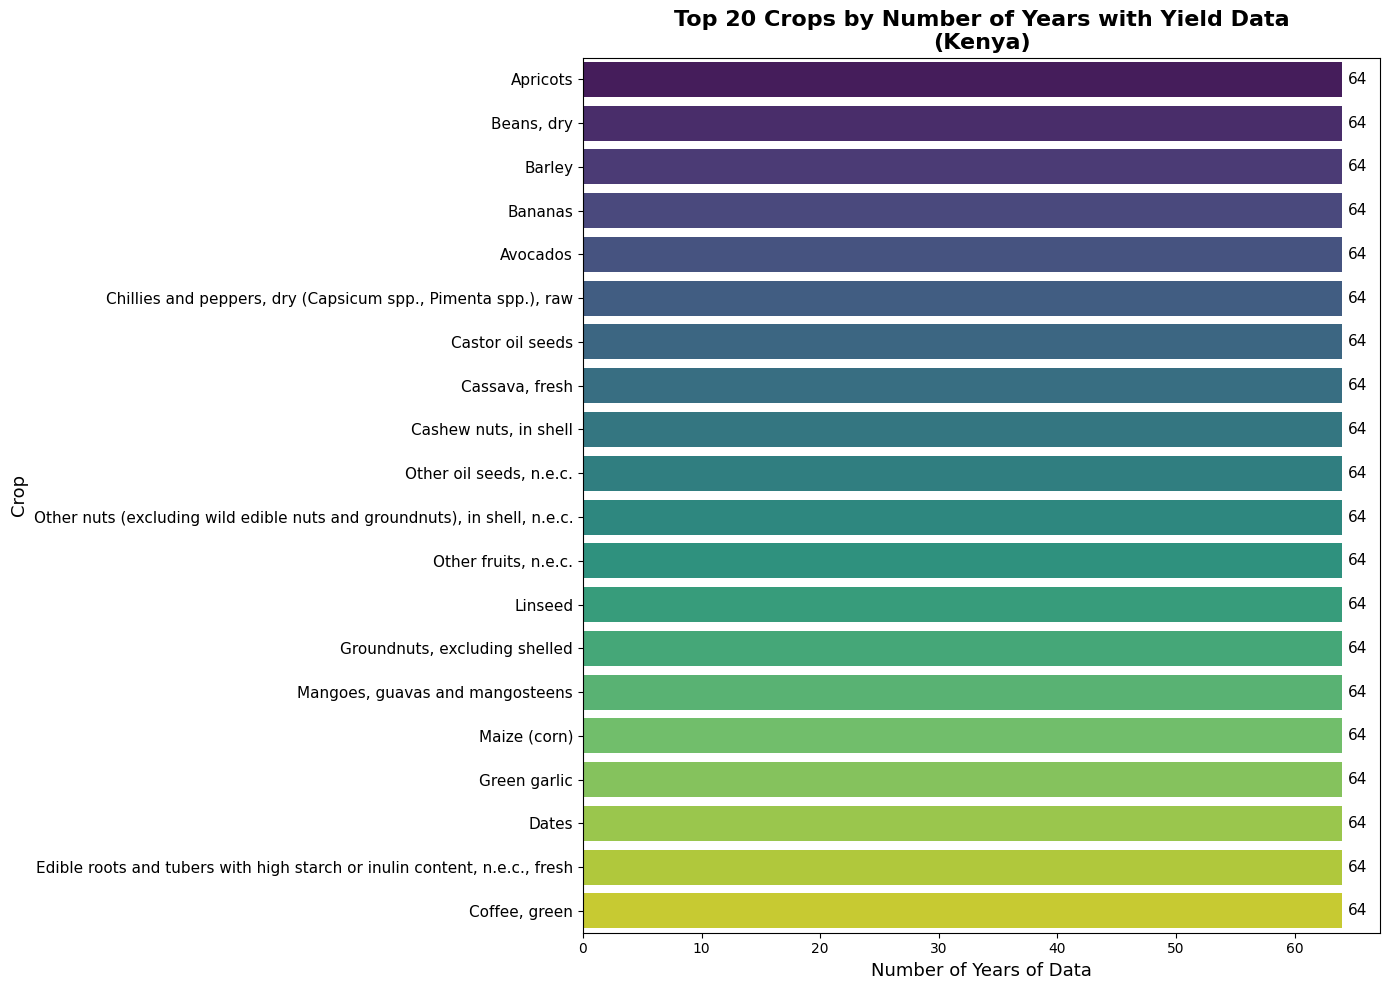

In [37]:
# Top 15 crops crops

crop_years = yield_clean['item'].value_counts().head(20)

plt.figure(figsize=(14,10))
ax =sns.barplot(
    y=crop_years.index,
    x=crop_years.values,
    palette ='viridis'
)


plt.title('Top 20 Crops by Number of Years with Yield Data\n(Kenya)',
           fontsize=16,fontweight='bold')
plt.xlabel('Number of Years of Data', fontsize=13)
plt.ylabel('Crop', fontsize=13)

# Adding value labels
for i, v in enumerate(crop_years.values):
    ax.text(v + 0.5, i, str(v), va='center',fontsize=11,fontweight='medium')

plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Saving the Cleaned Data

In [38]:
yield_clean.to_csv('yield_cleaned.csv', index=False)
